# 🚀 Play Store: Market Trends & Sentiment Analysis

Welcome to this end-to-end data science project! In this notebook, we analyze the Google Play Store ecosystem to uncover hidden market patterns, user behaviors, and the relationship between app characteristics and user satisfaction.

### 📌 Project Workflow
1. **Data Cleaning:** Handling missing values and ensuring data integrity.
2. **Exploratory Data Analysis (EDA):** Visualizing market supply vs. user demand.
3. **Sentiment Analysis (NLP):** Decoding user feedback using Machine Learning.
4. **Real-time Prediction:** A live demo of our sentiment analysis model.

---
*Built by a passionate software engineer focusing on data-driven solutions.*

In [1]:
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub

/kaggle/input/datasets/lava18/google-play-store-apps/googleplaystore.csv
/kaggle/input/datasets/lava18/google-play-store-apps/license.txt
/kaggle/input/datasets/lava18/google-play-store-apps/googleplaystore_user_reviews.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/lava18/google-play-store-apps/googleplaystore.csv')
df.tail()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


In [3]:
df.info()

print("\n--- Missing data numbers ---")

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB

--- Missing data numbers ---


App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [4]:
df['Installs'] = df['Installs'].str.replace('+', '')
df['Installs'] = df['Installs'].str.replace(',', '')

df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

df[['App', 'Installs']].head()

,App,Installs
0,Photo Editor & Candy Camera & Grid & ScrapBook,10000.0
1,Coloring book moana,500000.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",5000000.0
3,Sketch - Draw & Paint,50000000.0
4,Pixel Draw - Number Art Coloring Book,100000.0


In [5]:
# We are removing the '$' sign from the 'Price' column
df['Price'] = df['Price'].str.replace('$', '')

# We convert the cleaned prices to decimal numbers (floats)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

df[df['Price'] > 0][['App', 'Price']].head()

,App,Price
234,TurboScan: scan documents and receipts in PDF,4.99
235,Tiny Scanner Pro: PDF Doc Scan,4.99
290,TurboScan: scan documents and receipts in PDF,4.99
291,Tiny Scanner Pro: PDF Doc Scan,4.99
427,Puffin Browser Pro,3.99


In [6]:
df['Size'] = df['Size'].replace('Varies with device', pd.NA)

def convert_size(size):
    if pd.isna(size): 
        return size
    size_str = str(size)
    if 'M' in size_str:
        return float(size_str.replace('M', '')) 
    elif 'k' in size_str:
        return float(size_str.replace('k', '')) / 1024     
    else:
        return pd.to_numeric(size, errors='coerce')

df['Size'] = df['Size'].apply(convert_size)

df[['App', 'Size']].head()

,App,Size
0,Photo Editor & Candy Camera & Grid & ScrapBook,19.0
1,Coloring book moana,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",8.7
3,Sketch - Draw & Paint,25.0
4,Pixel Draw - Number Art Coloring Book,2.8


In [7]:
df.dropna(inplace=True)

print(f"Total number of clean applications remaining after cleaning: {df.shape[0]}")

Total number of clean applications remaining after cleaning: 7723


In [8]:
df.drop_duplicates(subset=['App'], keep='first', inplace=True)

df['Reviews'] = df['Reviews'].astype(int)

print(f"The unique, clear number of applications remaining after duplicate data has been deleted: {df.shape[0]}")
print("New data type for Reviews column:", df['Reviews'].dtype)

The unique, clear number of applications remaining after duplicate data has been deleted: 7023
New data type for Reviews column: int64


In [9]:
df['Size'] = df['Size'].astype(float)

df['Last Updated'] = pd.to_datetime(df['Last Updated'])

print(df[['Size', 'Last Updated']].dtypes)

Size                   float64
Last Updated    datetime64[ns]
dtype: object


In [10]:
df.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7023 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             7023 non-null   object        
 1   Category        7023 non-null   object        
 2   Rating          7023 non-null   float64       
 3   Reviews         7023 non-null   int64         
 4   Size            7023 non-null   float64       
 5   Installs        7023 non-null   float64       
 6   Type            7023 non-null   object        
 7   Price           7023 non-null   float64       
 8   Content Rating  7023 non-null   object        
 9   Genres          7023 non-null   object        
 10  Last Updated    7023 non-null   datetime64[ns]
 11  Current Ver     7023 non-null   object        
 12  Android Ver     7023 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(7)
memory usage: 768.1+ KB


In [12]:
df.tail()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10833,Chemin (fr),BOOKS_AND_REFERENCE,4.8,44,0.604492,1000.0,Free,0.0,Everyone,Books & Reference,2014-03-23,0.8,2.2 and up
10834,FR Calculator,FAMILY,4.0,7,2.600000,500.0,Free,0.0,Everyone,Education,2017-06-18,1.0.0,4.1 and up
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53.000000,5000.0,Free,0.0,Everyone,Education,2017-07-25,1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.600000,100.0,Free,0.0,Everyone,Education,2018-07-06,1.0,4.1 and up
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19.000000,10000000.0,Free,0.0,Everyone,Lifestyle,2018-07-25,Varies with device,Varies with device


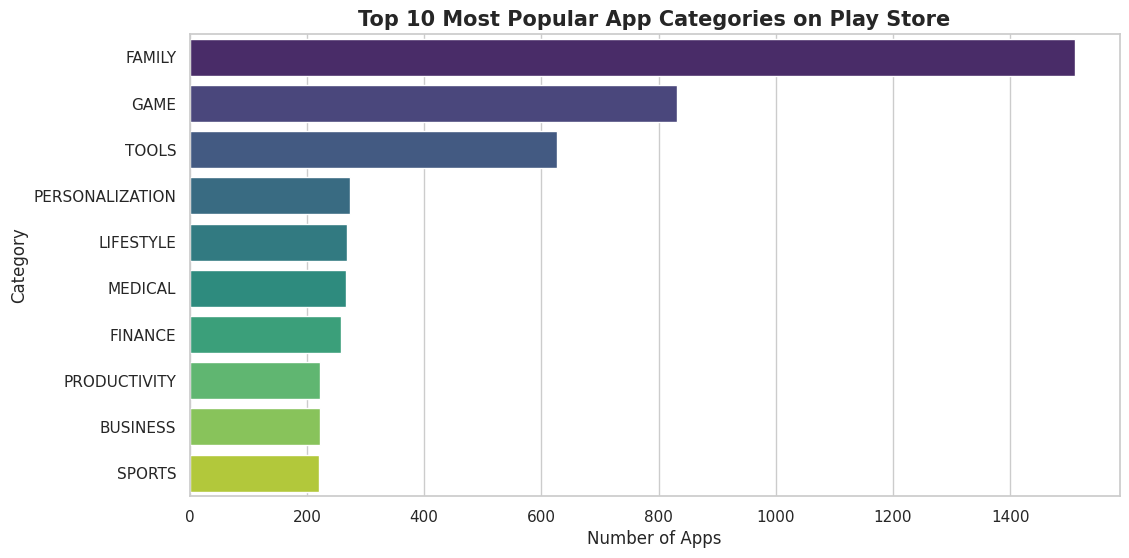

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting a modern and clean theme for our plots
sns.set_theme(style="whitegrid")

# Finding the top 10 most common app categories in the dataset
plt.figure(figsize=(12, 6))
category_counts = df['Category'].value_counts().head(10)

# Creating the Bar Plot
sns.barplot(x=category_counts.values, y=category_counts.index, hue=category_counts.index, palette="viridis", legend=False)

plt.title("Top 10 Most Popular App Categories on Play Store", fontsize=15, weight='bold')
plt.xlabel("Number of Apps", fontsize=12)
plt.ylabel("Category", fontsize=12)

plt.show()

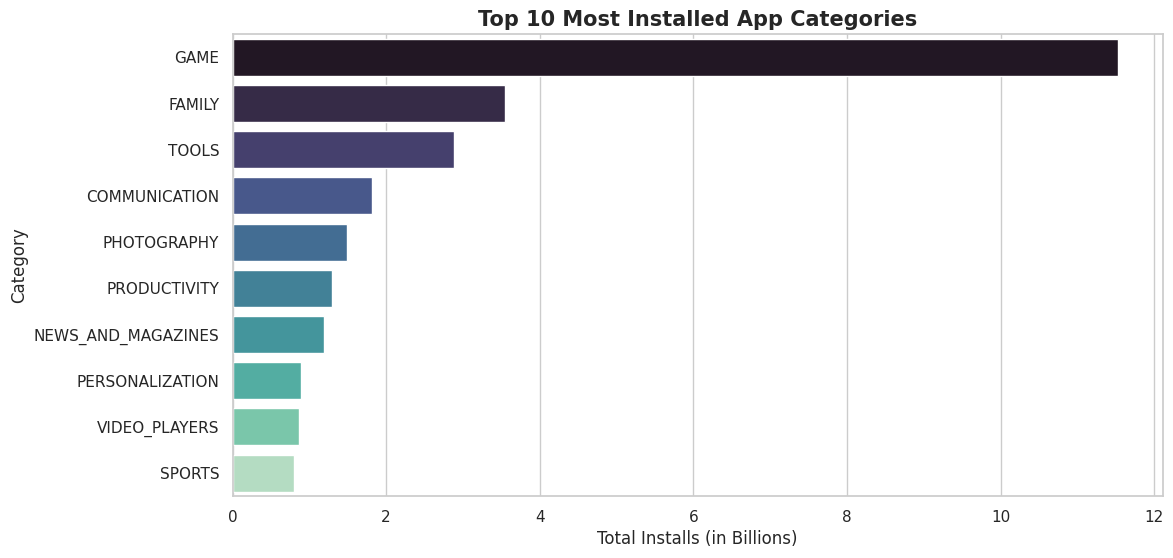

In [14]:
# Grouping apps by category and calculating the total number of installs
# Dividing by 1 billion (1e9) to make the x-axis numbers clean and readable
category_installs = df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10) / 1e9

plt.figure(figsize=(12, 6))

sns.barplot(x=category_installs.values, y=category_installs.index, hue=category_installs.index, palette="mako", legend=False)

plt.title("Top 10 Most Installed App Categories", fontsize=15, weight='bold')
plt.xlabel("Total Installs (in Billions)", fontsize=12)
plt.ylabel("Category", fontsize=12)

plt.show()

### Key Insights: Supply vs. Demand
* **The Developer Bias:** The first chart indicates that developers primarily focus on creating **Family** apps. However, user demand for this category is disproportionately low.
* **Gaming Dominance:** While **Games** are second in terms of app volume, they completely dominate the market in actual user acquisition (over 11 Billion installs).
* **The Giant Monopoly:** Categories like **Communication** and **Video Players** have relatively few apps but billions of installs. This clearly points to a market dominated by a few tech giants (e.g., WhatsApp, YouTube). 

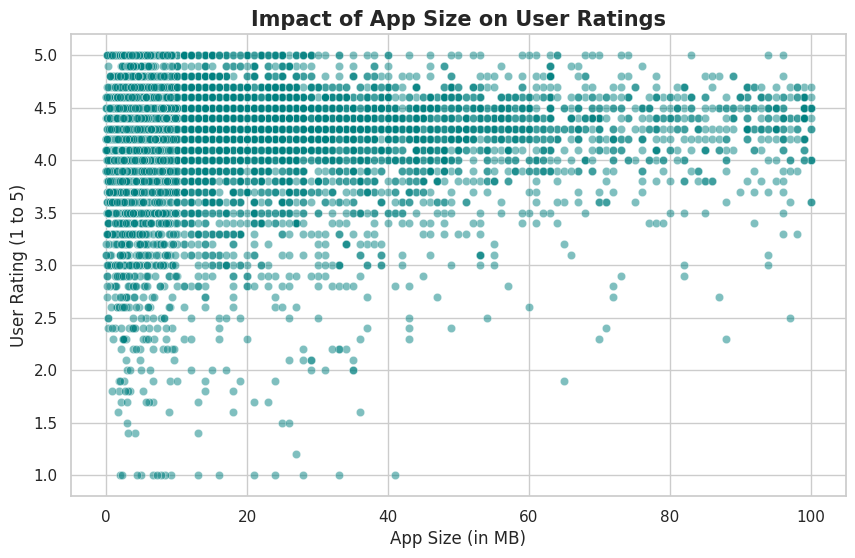

In [15]:
plt.figure(figsize=(10, 6))

# Creating a Scatter Plot to analyze App Size vs. User Rating
# 'alpha=0.5' makes the dots slightly transparent so we can see where they overlap and cluster
sns.scatterplot(data=df, x='Size', y='Rating', alpha=0.5, color='teal')

plt.title("Impact of App Size on User Ratings", fontsize=15, weight='bold')
plt.xlabel("App Size (in MB)", fontsize=12)
plt.ylabel("User Rating (1 to 5)", fontsize=12)

plt.show()

### Key Insights: Does App Size Matter?
* **The "Lightweight" Clutter:** Apps under 30 MB show extreme variance in user ratings, ranging from 1.0 to 5.0. This indicates that while small apps are easy to produce, they often suffer from poor quality or spam-like behavior.
* **Heavyweight Quality:** As app size increases (especially >60 MB), the user ratings strictly cluster above 3.5. 
* **Conclusion:** Users do not penalize apps for being large. If an app requires more storage due to rich features, high-quality UI, or complex logic, users are highly likely to reward it with a top-tier rating.

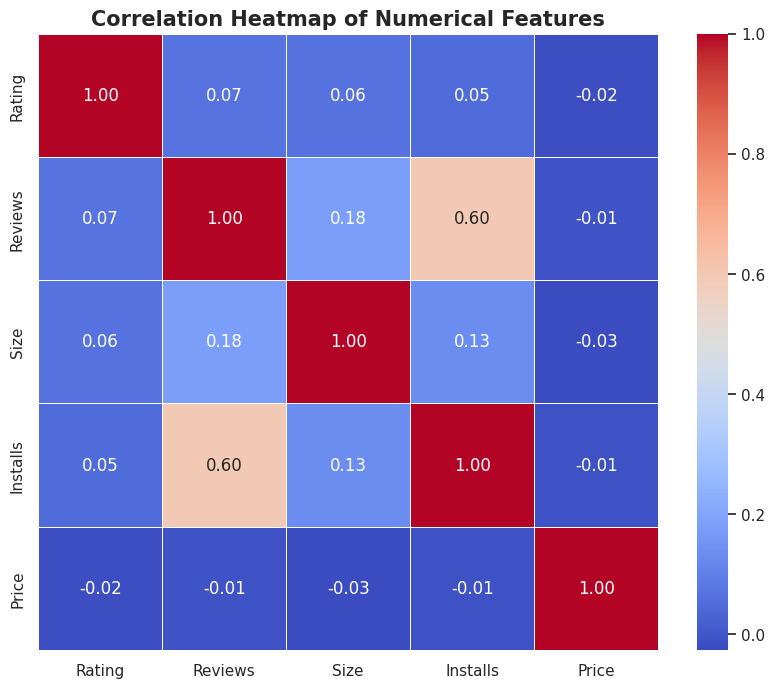

In [16]:
plt.figure(figsize=(10, 8))

# Calculating the correlation matrix specifically for numerical columns
numerical_cols = ['Rating', 'Reviews', 'Size', 'Installs', 'Price']
corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap of Numerical Features", fontsize=15, weight='bold')

plt.show()

### Key Insights: Correlation Matrix
* **The Success Metric (Installs & Reviews):** There is a highly positive correlation between `Installs` and `Reviews`. This confirms a strong market rule: apps with massive download numbers generate exponential user engagement and community feedback.
* **Price vs. Popularity:** `Price` shows a slightly negative or near-zero correlation with `Installs`. This aligns with the reality of the mobile ecosystem where the vast majority of user acquisition happens in free apps.
* **Rating Independence:** `Rating` has very weak correlations with `Size` and `Price`. This mathematically proves our previous hypothesis: users strictly evaluate an app based on its quality and performance, regardless of how much space it takes or whether it costs money.

In [17]:
reviews_df = pd.read_csv('/kaggle/input/datasets/lava18/google-play-store-apps/googleplaystore_user_reviews.csv')

reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [18]:
# Checking the number of missing values before cleaning
print("Before cleaning (Missing Values):")
print(reviews_df.isnull().sum())

# Dropping rows where either the review text or the sentiment label is missing
reviews_df.dropna(subset=['Translated_Review', 'Sentiment'], inplace=True)

# Confirming the final shape of the clean dataset
print(f"\nAfter cleaning: {reviews_df.shape[0]} clean user reviews remain.")

Before cleaning (Missing Values):
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

After cleaning: 37427 clean user reviews remain.


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Defining the Features (X) and the Target (y)
X = reviews_df['Translated_Review']
y = reviews_df['Sentiment']

# Splitting the data: 80% for training the model, 20% for testing its knowledge
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# We limit to the top 5000 most frequent words for optimal performance
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Training the Machine Learning Model (Logistic Regression)
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

predictions = model.predict(X_test_vec)

# Evaluating the model's success
accuracy = accuracy_score(y_test, predictions)
print(f"Machine Learning Model Accuracy: {accuracy * 100:.2f}%")

Machine Learning Model Accuracy: 89.61%


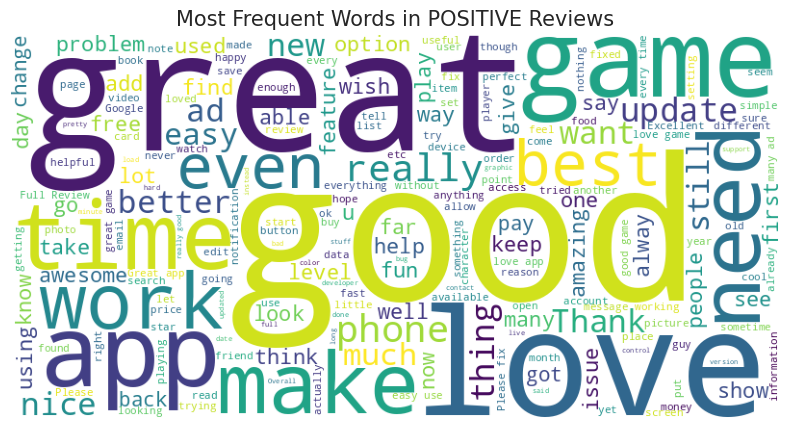

In [20]:
from wordcloud import WordCloud

# Creating a subset for Positive and Negative reviews
pos_reviews = " ".join(reviews_df[reviews_df['Sentiment'] == 'Positive']['Translated_Review'])
neg_reviews = " ".join(reviews_df[reviews_df['Sentiment'] == 'Negative']['Translated_Review'])

plt.figure(figsize=(10, 5))
plt.imshow(WordCloud(width=800, height=400, background_color='white').generate(pos_reviews))
plt.title("Most Frequent Words in POSITIVE Reviews", fontsize=15)
plt.axis('off')
plt.show()

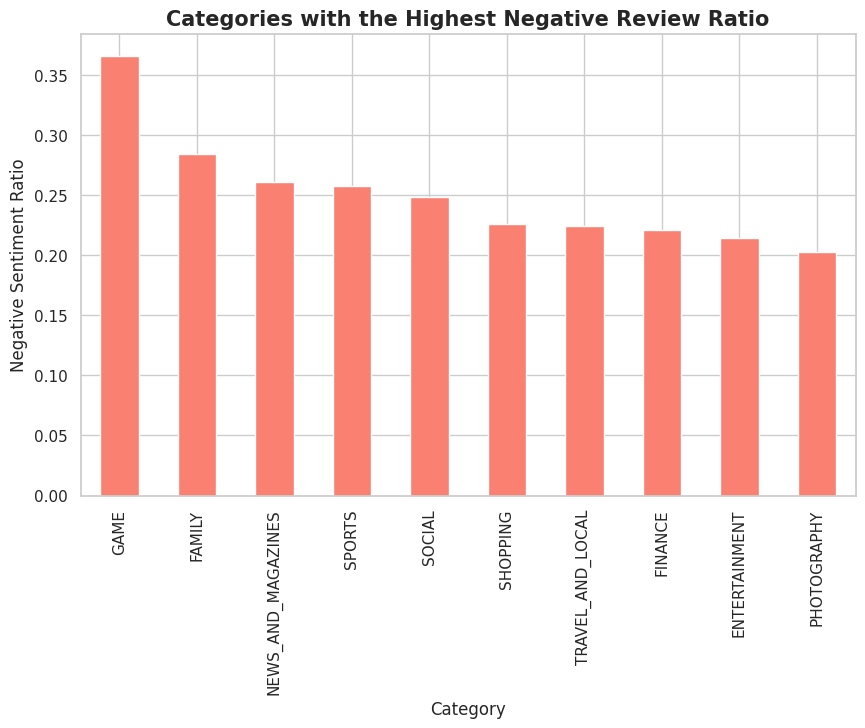

In [21]:
# Merging the two datasets on the 'App' column
merged_df = pd.merge(df[['App', 'Category']], reviews_df, on='App')

# Calculating the percentage of negative sentiments per category
negative_sentiment = merged_df[merged_df['Sentiment'] == 'Negative'].groupby('Category').size()
total_sentiment = merged_df.groupby('Category').size()
neg_ratio = (negative_sentiment / total_sentiment).sort_values(ascending=False)

# Visualizing the Categories with the highest dissatisfaction
plt.figure(figsize=(10, 6))
neg_ratio.head(10).plot(kind='bar', color='salmon')
plt.title("Categories with the Highest Negative Review Ratio", fontsize=15, weight='bold')
plt.ylabel("Negative Sentiment Ratio")
plt.show()

### Strategic Takeaways: User Sentiment & Quality Analysis

* **The Positive Experience (WordCloud Insights):** The most frequent words in positive reviews—such as **"great", "good", "love", "best"**—highlight that users value simplicity and utility. When developers focus on core functionalities and user-centric features, positive engagement follows naturally.
* **The Critical Bottleneck (Negative Sentiment Ratio):** Despite being the most popular categories, **Game** and **Family** apps suffer from the highest negative sentiment ratios.
* **Business Opportunity:** This discrepancy represents a significant opportunity for developers. There is a clear market demand for these categories, but users are currently dissatisfied with the execution (likely due to bugs, ads, or performance issues). Improving the quality of these specific categories could be a high-impact strategy for future development.

In [22]:
# Function to predict the sentiment of any custom input string
def predict_sentiment(review_text):
    vec = vectorizer.transform([review_text])
    # Make prediction
    prediction = model.predict(vec)
    return prediction[0]

# Testing the model with a custom review
new_review = "I really love this app, it's very helpful!"
result = predict_sentiment(new_review)

print(f"Review: '{new_review}'")
print(f"Predicted Sentiment: {result}")

Review: 'I really love this app, it's very helpful!'
Predicted Sentiment: Positive


### Real-Time Sentiment Prediction Demo
* **Integration Capability:** Beyond static analysis, the trained model is encapsulated into a functional pipeline. By utilizing `TF-IDF Vectorization` and `Logistic Regression`, the system can process raw, unstructured user input and classify its sentiment in real-time.
* **Scalability:** This predictive architecture can be seamlessly integrated into existing mobile application backends to monitor user feedback loops, flag negative reviews for customer support teams, or track sentiment shifts after major app updates.
* **Final Project Vision:** This project demonstrates a holistic approach to data science: from cleaning raw datasets to generating business intelligence insights and deploying machine learning models to drive automated decision-making.